# Pitch primitives — `yin` / `psola` / `pvoc`: verification & findings

The three pitch primitives, measured. Like the other Tap notebooks, every cell drives the
**actual shipping DSP** — the same headers the consuming libraries compile — through the C ABI
in `tools/capi/`, loaded via ctypes (`dsptap_py.py`). Nothing here is a Python re-implementation
of the shipping code (the one deliberate exception is the *naive* phase vocoder in §3, which
exists precisely to show why the shipping design is different).

Contents:

1. **YIN accuracy** — the detector's sub-cent contract, measured across the range.
2. **Finding 1 — PSOLA is a spectral-envelope resampler.** A pure tone shifted an octave
   nearly vanishes; that is the *same property* that makes PSOLA formant-preserving on voice.
3. **Finding 2 — naive phase-vocoder remapping loses half the level.** The textbook
   `round(k·ratio)` scheme vs the shipping peak-locked design, side by side.
4. **Formant preservation** — the LPC source-filter option on `pvoc`, holding a synthetic
   formant in place through a shift.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import dsptap_py as tap

plt.rcParams.update({
    "figure.dpi": 96, "figure.figsize": (9, 3.2),
    "axes.grid": True, "grid.alpha": 0.3,
})
C = tap.PALETTE

sr = 48000.0

def sine(freq, seconds=1.0, amp=1.0):
    t = np.arange(int(seconds * sr))
    return amp * np.sin(2 * np.pi * freq * t / sr)

def saw(freq, seconds=1.0, harmonics=20):
    t = np.arange(int(seconds * sr))
    x = sum(np.sin(2 * np.pi * freq * h * t / sr) / h for h in range(1, harmonics + 1))
    return x / np.abs(x).max()

def detector():
    return tap.Yin(window=873, tau_min=24, tau_max=873)   # 55 Hz .. 2 kHz at 48k

def measure_hz(x):
    d = detector()
    period, _ = d.analyze(x[-d.frame_size:])
    return sr / period if period > 0 else 0.0

def cents(f, ref):
    return 1200 * np.log2(f / ref)

def spectrum_db(x, n=8192):
    w = np.hanning(n)
    X = np.abs(np.fft.rfft(x[-n:] * w))
    f = np.fft.rfftfreq(n, 1 / sr)
    return f, 20 * np.log10(np.maximum(X / X.max(), 1e-6))

## 1 · YIN: sub-cent period accuracy on the material it claims

`yin.h` implements de Cheveigné & Kawahara steps 1–5 with parabolic sub-sample lag refinement.
The contract (pinned in `tests/test_yin.cpp`) is sub-cent accuracy on clean periodic material in
the double profile, including deliberately non-integer periods, and octave-robustness on
harmonic-rich sawtooth — the classic trap for naive autocorrelation.

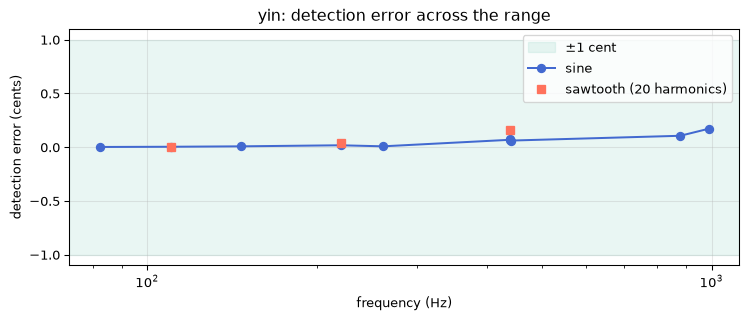

worst sine error: 0.170 cents
worst saw  error: 0.155 cents  (no octave errors)


In [2]:
freqs = [82.4, 110.0, 146.8, 220.0, 261.6, 439.7, 440.0, 441.3, 880.0, 987.8]
err_sine = [cents(measure_hz(sine(f)), f) for f in freqs]
err_saw  = [cents(measure_hz(saw(f)), f) for f in [110.0, 220.0, 440.0]]

fig, ax = plt.subplots()
ax.axhspan(-1, 1, color=C[3], alpha=0.15, label="±1 cent")
ax.semilogx(freqs, err_sine, "o-", color=C[0], label="sine")
ax.semilogx([110, 220, 440], err_saw, "s", color=C[2], label="sawtooth (20 harmonics)")
ax.set(xlabel="frequency (Hz)", ylabel="detection error (cents)",
       title="yin: detection error across the range")
ax.legend()
plt.show()

print(f"worst sine error: {max(abs(e) for e in err_sine):.3f} cents")
print(f"worst saw  error: {max(abs(e) for e in err_saw):.3f} cents  (no octave errors)")

## 2 · Finding 1 — PSOLA resamples the spectral envelope

TD-PSOLA re-spaces period-synchronous grains; the output's new harmonics *sample the source's
spectral envelope*. Two consequences, one good and one that looks like a bug until you see they
are the same thing:

- On **voice-like (harmonic-rich) material**, the envelope — the formants — stays put while the
  pitch moves. That is exactly why PSOLA is the classic *formant-preserving* vocal shifter.
- On a **pure tone**, the envelope is a single spike. Shift up an octave and the new harmonic
  grid (2f₀, 4f₀, …) has no member left at the spike — the output all but vanishes. First
  encountered as a "failing test" here; it is the algorithm working exactly as published, and
  `tests/test_psola.cpp` now pins it on purpose (`PureToneOctaveUpThinsOut`).

Below: the same octave-up shift on a sine (vanishes) and on a sawtooth (healthy, envelope kept).

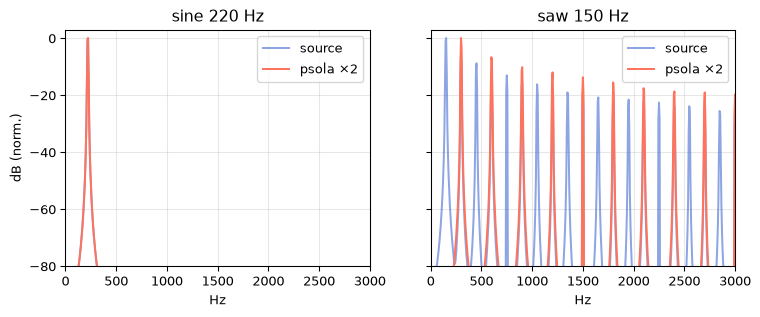

output peak, sine ×2: 0.0000   (thins out — envelope spike missed)
output peak, saw  ×2: 0.4808   (healthy — envelope sampled by new harmonics)
saw output pitch: 300.0 Hz (target 300.0)


In [3]:
ratio = 2.0
x_sine, x_saw = sine(220.0), saw(150.0)

p1, p2 = tap.Psola(900), tap.Psola(900)
y_sine = p1.process(x_sine, period=sr / 220.0, ratio=ratio)
y_saw  = p2.process(x_saw,  period=sr / 150.0, ratio=ratio)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharey=True)
for ax, (src, out, name, f0) in zip(axes, [(x_sine, y_sine, "sine 220 Hz", 220.0),
                                           (x_saw, y_saw, "saw 150 Hz", 150.0)]):
    f, S = spectrum_db(src)
    ax.plot(f, S, color=C[0], alpha=0.6, label="source")
    f, S = spectrum_db(out + 1e-12)
    ax.plot(f, S, color=C[2], label=f"psola ×{ratio:g}")
    ax.set(xlim=(0, 3000), ylim=(-80, 3), xlabel="Hz", title=name)
    ax.legend(loc="upper right")
axes[0].set_ylabel("dB (norm.)")
plt.show()

print(f"output peak, sine ×2: {np.abs(y_sine[-4800:]).max():.4f}   (thins out — envelope spike missed)")
print(f"output peak, saw  ×2: {np.abs(y_saw[-4800:]).max():.4f}   (healthy — envelope sampled by new harmonics)")
print(f"saw output pitch: {measure_hz(y_saw):.1f} Hz (target {150 * ratio:.1f})")

## 3 · Finding 2 — naive phase-vocoder remapping guts the level

The textbook-simple pitch shifter — remap each analysis bin `k` to `round(k·ratio)` and
accumulate each synthesis bin's phase from its own frequency estimate — has two structural
problems, both measured below on the *same* geometry (1024-point Hann, 4× overlap):

1. A peak's Hann mainlobe bins land on **scattered** target bins (for 220 Hz × 1.5: bins
   {5, 6, 8, 9} — nothing at the true target 7.04), and free-running per-bin phases destroy the
   phase relationships across the lobe. The overlap-add then partially cancels: **less than half
   the level survives** at fractional ratios.
2. Even at ratio 1 the reconstruction is not the input waveform (phases are accumulated, not
   carried).

The shipping `pvoc.h` uses Laroche–Dolson-style **peak-region shifting** instead: each peak's
whole region translates rigidly by an integer bin offset (lobe pattern intact) and rotates by one
accumulated per-hop phase — which must carry the **full** frequency difference `f·(ratio−1)`,
because the integer shift's implicit modulator is frame-relative (the subtle bug found while
building this: accumulating only the sub-bin residual desynchronizes the overlap-add). Result:
sub-cent accuracy, ~0.95 level everywhere, and *exact* waveform identity at ratio 1.

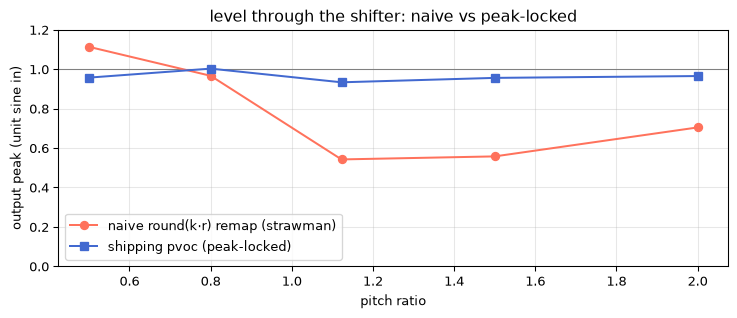

shipping pvoc, worst identity error at ratio 1 (one frame late): 7.77e-16
shipping pvoc pitch at ratio 1.5: 330.02 Hz (target 330.00)


In [4]:
def naive_pv_shift(x, ratio, n=1024, overlap=4):
    """The textbook strawman (deliberately NOT the shipping algorithm)."""
    hop = n // overlap
    win = np.hanning(n + 1)[:n]
    cola = 1.5  # sum of win^2 at hop stride
    expected = 2 * np.pi * hop / n
    prev_phase = np.zeros(n // 2 + 1)
    synth_phase = np.zeros(n // 2 + 1)
    y = np.zeros(len(x) + n)
    for start in range(0, len(x) - n, hop):
        X = np.fft.rfft(x[start:start + n] * win)
        mag, phase = np.abs(X), np.angle(X)
        delta = phase - prev_phase - expected * np.arange(len(X))
        prev_phase = phase
        delta -= 2 * np.pi * np.round(delta / (2 * np.pi))
        true_bin = np.arange(len(X)) + delta / expected
        syn_mag = np.zeros_like(mag); syn_bin = np.zeros_like(mag)
        for k in range(1, len(X) - 1):
            j = int(round(k * ratio))
            if 1 <= j < len(X) - 1:
                syn_mag[j] += mag[k]; syn_bin[j] = true_bin[k] * ratio
        synth_phase += expected * syn_bin
        Y = syn_mag * np.exp(1j * synth_phase)
        y[start:start + n] += np.fft.irfft(Y) * win / cola
    return y[:len(x)]

ratios = [0.5, 0.8, 1.122462, 1.5, 2.0]
x = sine(220.0)
level_naive, level_locked = [], []
for r in ratios:
    yn = naive_pv_shift(x, r)
    yl = tap.Pvoc(1024).process(x, r)
    level_naive.append(np.abs(yn[-4800:]).max())
    level_locked.append(np.abs(yl[-4800:]).max())

fig, ax = plt.subplots()
ax.axhline(1.0, color="gray", lw=0.8)
ax.plot(ratios, level_naive, "o-", color=C[2], label="naive round(k·r) remap (strawman)")
ax.plot(ratios, level_locked, "s-", color=C[0], label="shipping pvoc (peak-locked)")
ax.set(xlabel="pitch ratio", ylabel="output peak (unit sine in)", ylim=(0, 1.2),
       title="level through the shifter: naive vs peak-locked")
ax.legend()
plt.show()

y1 = tap.Pvoc(1024).process(x, 1.0)
lat = tap.Pvoc(1024).latency
err = np.abs(y1[lat + 4800:lat + 9600] - x[4800:9600]).max()
print(f"shipping pvoc, worst identity error at ratio 1 (one frame late): {err:.2e}")
print(f"shipping pvoc pitch at ratio 1.5: {measure_hz(tap.Pvoc(1024).process(x, 1.5)):.2f} Hz (target 330.00)")

## 4 · Formant preservation — the LPC source-filter option

`pvoc.set_formant(true)` estimates each frame's spectral envelope by LPC (autocorrelation
method + Levinson–Durbin, order 48) and rescales every relocated bin by
`envelope(target) / envelope(source)`: the excitation moves, the envelope stays. Implemented
from the published source-filter literature only, per the project's IP policy; PSOLA needs no
such option (§2 — envelope preservation *is* its resampling rule), and at ratio 1 the correction
is exactly unity so the identity contract is untouched.

The test signal is a 160 Hz harmonic series with a synthetic "formant" — a Gaussian spectral
bump at 800 Hz. Shift up a fifth: plain shifting relocates the bump to 1200 Hz (chipmunk); with
formant preservation the pitch moves and the bump stays near 800 Hz.

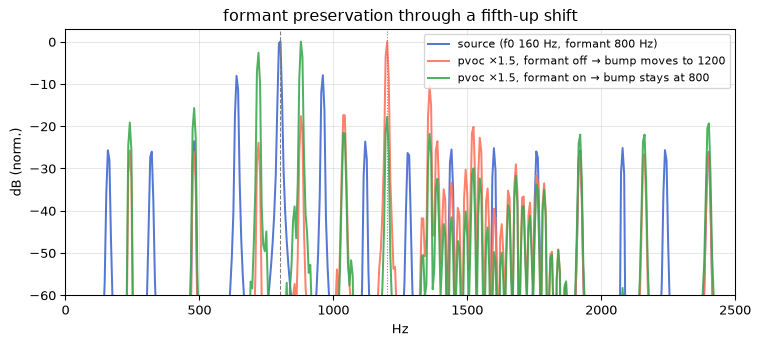

formant off: energy 600–1000 Hz / 1050–1450 Hz = 0.02, cepstral f0 = 240.0 Hz (target 240.0)
formant on : energy 600–1000 Hz / 1050–1450 Hz = 62.18, cepstral f0 = 240.0 Hz (target 240.0)


In [5]:
def formant_series(f0=160.0, center=800.0, seconds=1.0):
    t = np.arange(int(seconds * sr))
    x = sum((np.exp(-(((f0 * h) - center) / 150.0) ** 2) + 0.05)
            * np.sin(2 * np.pi * f0 * h * t / sr) for h in range(1, 21))
    return x / np.abs(x).max()

src = formant_series()
plain = tap.Pvoc(1024).process(src, 1.5)
kept  = tap.Pvoc(1024, formant=True).process(src, 1.5)

fig, ax = plt.subplots(figsize=(9, 3.6))
for x_, name, color in [(src, "source (f0 160 Hz, formant 800 Hz)", C[0]),
                        (plain, "pvoc ×1.5, formant off → bump moves to 1200", C[2]),
                        (kept, "pvoc ×1.5, formant on → bump stays at 800", C[4])]:
    f, S = spectrum_db(x_)
    ax.plot(f, S, color=color, label=name, alpha=0.9)
ax.axvline(800, color="gray", lw=0.8, ls="--")
ax.axvline(1200, color="gray", lw=0.8, ls=":")
ax.set(xlim=(0, 2500), ylim=(-60, 3), xlabel="Hz", ylabel="dB (norm.)",
       title="formant preservation through a fifth-up shift")
ax.legend(loc="upper right", fontsize=8)
plt.show()

def band(x_, lo, hi, n=4096):
    w = np.hanning(n); X = np.abs(np.fft.rfft(x_[-n:] * w)) ** 2
    f = np.fft.rfftfreq(n, 1 / sr)
    return X[(f >= lo) & (f <= hi)].sum()

def cepstral_f0(x_, n=8192, lo=100.0, hi=500.0):
    # cepstral f0 — the robust oracle for this bump-shaped synthetic, whose
    # weak fundamental makes a lag-domain first-dip rule ambiguous (a real
    # voice keeps enough fundamental for yin)
    X = np.abs(np.fft.rfft(x_[-n:] * np.hanning(n)))
    c = np.fft.irfft(np.log(X + 1e-9))
    q = np.arange(n // 2)
    valid = (q > sr / hi) & (q < sr / lo)
    return sr / q[valid][np.argmax(c[:n // 2][valid])]

for name, x_ in [("formant off", plain), ("formant on ", kept)]:
    print(f"{name}: energy 600–1000 Hz / 1050–1450 Hz = {band(x_, 600, 1000) / band(x_, 1050, 1450):.2f}, "
          f"cepstral f0 = {cepstral_f0(x_):.1f} Hz (target 240.0)")

## Summary

- **yin** holds its sub-cent contract across the range, with no octave errors on the saw.
- **psola** is honestly documented as a spectral-envelope resampler: near-silent on the
  octave-up pure tone, healthy and formant-preserving on harmonic material — one property,
  two faces (Finding 1).
- **pvoc**'s peak-locked design exists because the naive remap measurably loses over half its
  level at fractional ratios (Finding 2); the shipping code holds ~0.95 level, sub-cent
  accuracy, and exact identity at ratio 1, with LPC formant preservation as an option.

Every number above is produced by the shipping C++ through `tools/capi`; the corresponding
hard gates live in `tests/test_yin.cpp`, `tests/test_psola.cpp`, and `tests/test_pvoc.cpp`.